# EUR/USD Forecasting Using Machine Learning

This notebook demonstrates how I built and deployed a machine learning pipeline to predict EUR/USD price changes using time series data, technical indicators, PCA, and XGBoost. It includes buy/sell model predictions, and a final combo model that synthesizes results to make trade decisions. In the description when I mention candle I'm refering to the time periods Open,High,Low,Close.  In this instance each candle represents 4 hours of trade data.


## Importing Libraries
This section imports all necessary libraries including data processing, modeling, and visualization tools.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import joblib
import optuna
import plotly.express as px
plt.style.use('seaborn-v0_8-whitegrid')


## Loading and Preprocessing Data
This section loads the EUR/USD historical dataset, parses the timestamps, and prepares the data for analysis. It then displays a portion of the data both as a preview table and a candlestick chart to help visually inspect recent market behavior.

Chart Head:
            timestamp     open     high      low    close  tick_volume
0 2023-07-27 00:00:00  1.10854  1.10896  1.10747  1.10867         8650
1 2023-07-27 04:00:00  1.10866  1.11178  1.10866  1.10959        17876
2 2023-07-27 08:00:00  1.10957  1.11393  1.10879  1.11390        25103
3 2023-07-27 12:00:00  1.11391  1.11498  1.10475  1.10590        26725
4 2023-07-27 16:00:00  1.10590  1.10652  1.09838  1.09902        35451
Chart Tail
               timestamp     open     high      low    close  tick_volume
3103 2025-07-25 04:00:00  1.17546  1.17586  1.17340  1.17402        14002
3104 2025-07-25 08:00:00  1.17401  1.17607  1.17372  1.17433        20893
3105 2025-07-25 12:00:00  1.17432  1.17437  1.17112  1.17182        21600
3106 2025-07-25 16:00:00  1.17183  1.17387  1.17029  1.17290        26594
3107 2025-07-25 20:00:00  1.17288  1.17471  1.17287  1.17393        14674


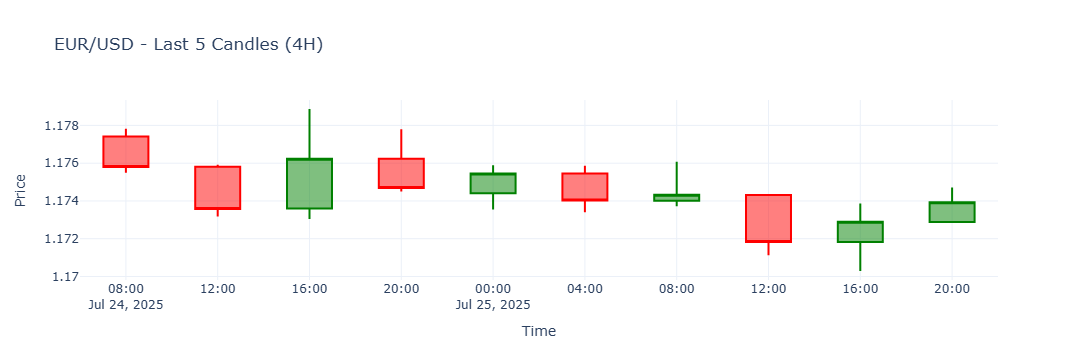

In [25]:
import MetaTrader5 as mt5
import pandas as pd
from datetime import datetime, timedelta
import plotly.graph_objects as go

def download_mt5_data(
    symbol="EURUSD!",
    timeframe=mt5.TIMEFRAME_H4,
    years=2,
    output_file="eurusd_4h_2years.csv"
):
    """
    Downloads historical 4-hour price data from MetaTrader 5.
    Falls back to CSV if MT5 is unavailable.
    Returns a DataFrame with timestamp, open, high, low, close, tick_volume.
    """

    try:
        if not mt5.initialize():
            raise RuntimeError(f"MT5 initialization failed: {mt5.last_error()}")

        end_time = datetime.now()
        start_time = end_time - timedelta(days=365 * years)

        if not mt5.symbol_select(symbol, True):
            raise RuntimeError(f"Failed to select symbol {symbol}")

        rates = mt5.copy_rates_range(symbol, timeframe, start_time, end_time)
        mt5.shutdown()

        if rates is None or len(rates) == 0:
            raise ValueError(f"No data returned for {symbol}.")

        df = pd.DataFrame(rates)
        df['timestamp'] = pd.to_datetime(df['time'], unit='s')
        df = df[['timestamp', 'open', 'high', 'low', 'close', 'tick_volume']]

        return df

    except Exception as e:
        print(f"MT5 data download failed: {e}")
        print("Loading fallback data from CSV...")
        df = pd.read_csv(output_file, parse_dates=['timestamp'])
        return df



df_raw = download_mt5_data()
print("Chart Head:")
print(df_raw.head())
print("Chart Tail")
print(df_raw.tail())

tail_df = df_raw.tail(10)
fig = go.Figure(data=[go.Candlestick(
    x=tail_df['timestamp'],
    open=tail_df['open'],
    high=tail_df['high'],
    low=tail_df['low'],
    close=tail_df['close'],
    increasing_line_color='green',
    decreasing_line_color='red'
)])

fig.update_layout(
    title="EUR/USD - Last 5 Candles (4H)",
    xaxis_title="Time",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False,
    template='plotly_white'
)

fig.show()



## Feature Engineering
This section prepares the dataset for modeling by removing rows with missing target labels and sorting by timestamp to maintain proper temporal structure.

Note: This notebook showcases only a minimal set of features. The full production model includes additional engineered features such as smoothed technical indicators, PCA components, and lagged values for improved predictive performance. 

Below, we also output a couple of waveforms to visualize the time series data.

Feature data head:
            timestamp     open     high      low    close  tick_volume  \
0 2023-08-11 12:00:00  1.09995  1.10050  1.09658  1.09682        24703   
1 2023-08-11 16:00:00  1.09680  1.09837  1.09455  1.09464        32370   
2 2023-08-11 20:00:00  1.09465  1.09557  1.09420  1.09424        17300   
3 2023-08-14 00:00:00  1.09458  1.09524  1.09360  1.09372         7369   
4 2023-08-14 04:00:00  1.09371  1.09409  1.09291  1.09357        20525   

      MA_10     MA_30     MA_60  Slope_MA_10  Slope_MA_30  Slope_MA_60  \
0  1.099455  1.098732  1.098165     0.000271     0.000160    -0.000054   
1  1.099209  1.098440  1.098033     0.000260     0.000121    -0.000048   
2  1.098839  1.098243  1.097918     0.000187     0.000082    -0.000040   
3  1.098027  1.098001  1.097777     0.000036     0.000027    -0.000034   
4  1.096963  1.097798  1.097660    -0.000157    -0.000028    -0.000043   

   Hour_Of_Day  
0           12  
1           16  
2           20  
3            0  
4     

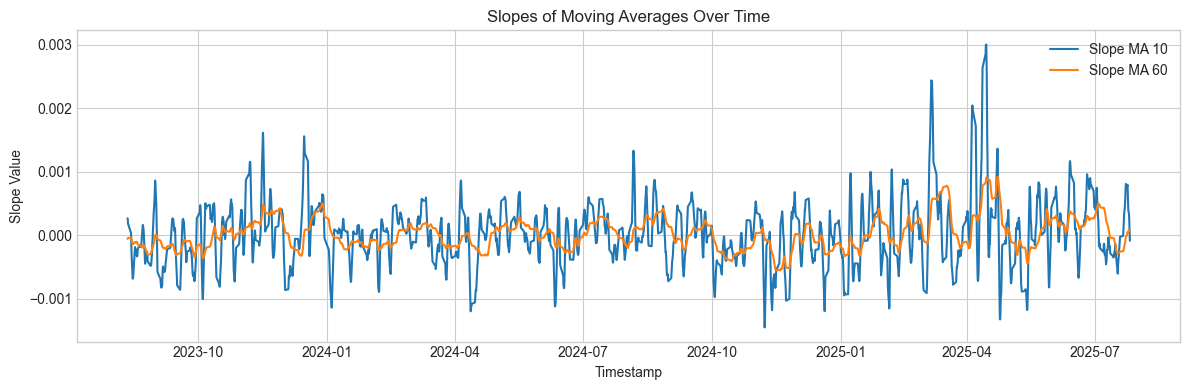

In [26]:

#Feature engineering.  This is a simplified version only showing a few standard features since this is a public notebook
def prepare_4h_dataframe(df_4h):
    
    
    df_4h['timestamp'] = pd.to_datetime(df_4h['timestamp'])


    # Add moving averages
    df_4h['MA_10'] = df_4h['close'].rolling(window=10).mean()
    df_4h['MA_30'] = df_4h['close'].rolling(window=30).mean()
    df_4h['MA_60'] = df_4h['close'].rolling(window=60).mean()

    # Slopes
    df_4h['Slope_MA_10'] = df_4h['MA_10'].diff(10) / 10
    df_4h['Slope_MA_30'] = df_4h['MA_30'].diff(10) / 10
    df_4h['Slope_MA_60'] = df_4h['MA_60'].diff(10) / 10

    # Time of Day
    df_4h['Hour_Of_Day'] = df_4h['timestamp'].dt.hour

    # Final clean-up
    df_4h.dropna(inplace=True)
    df_4h.reset_index(drop=True, inplace=True)

    return df_4h

df = prepare_4h_dataframe(df_raw)
print("Feature data head:")
print(df.head())



#Plot a couple of the features over the time series
plt.figure(figsize=(12, 4))
plt.plot(df['timestamp'], df['Slope_MA_10'], label='Slope MA 10')
plt.plot(df['timestamp'], df['Slope_MA_60'], label='Slope MA 60')

plt.title('Slopes of Moving Averages Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Slope Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Train Buy Model
Uses Optuna to find the best XGBoost parameters for each window then predict the test window with the best parameters.

In [ ]:


df_buy = df.copy()

df_buy['timestamp'] = pd.to_datetime(df_buy['timestamp'], errors='coerce')

 #This is the amount of candles to hold the trade.  So in this case all labels will be 2 candles ahead (8 hour trade)
max_hold = 2 
timestamp_buy = []
preds_buy_list=[]
actuals_buy_list=[]
timestamp_buy_list = []

#calculate Buy Model label which is the highest high in the next max_hold candles
future_high = pd.Series(index=df_buy.index, dtype=float)
for i in range(len(df_buy)):
    if i + 1 + max_hold <= len(df_buy):
        future_high.iloc[i] = df_buy['high'].iloc[i+1:i+1+max_hold].max()
    else:
        future_high.iloc[i] = np.nan
df_buy['label'] = (future_high - df_buy['close']) / 0.0001

# Create max drawdown.  The lowest low in the next max_hold candles
future_low = pd.Series(index=df_buy.index, dtype=float)

for i in range(len(df_buy)):
    if i + 1 + max_hold <= len(df_buy):
        future_low.iloc[i] = df_buy['low'].iloc[i+1:i+1+max_hold].min()
    else:
        future_low.iloc[i] = np.nan

df_buy['max_drawdown_pips'] = (future_low - df_buy['close']) / 0.0001




# Drop missing labels
df_buy = df_buy.dropna(subset=['label'])
df_buy_sorted = df_buy.sort_values(by='timestamp').reset_index(drop=True)


# Define features
exclude_cols = ['timestamp', 'date', 'label','max_drawdown_pips']
feature_cols = [col for col in df_buy.columns if col not in exclude_cols]
X = df_buy_sorted[feature_cols]
y = df_buy_sorted['label']





def weighted_rmse_obj(y_true, y_pred):
    residual = y_pred - y_true
    # Apply exponential weighting, capped to prevent extreme values
    weight = np.exp(y_true / y_true.max() * 2)  # Exponential from ~1 to ~e^2 (~7.4)
    weight = np.clip(weight, 1.0, 10.0)  # Ensure weight stays in a reasonable range
    grad = 2 * residual * weight
    hess = 2 * weight
    return grad, hess



def objective(trial, X_train_buy, y_train_buy, X_val, y_val):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.4),
        "subsample": trial.suggest_float("subsample", 0.5, 1),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1),
        "gamma": trial.suggest_float("gamma", 0, 7),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 7),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 7),
    }
    model_buy = XGBRegressor(**params, objective=weighted_rmse_obj, random_state=42)

    model_buy.fit(X_train_buy, y_train_buy)
    preds = model_buy.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))


# Walk forward
# Custom sliding window
n_total = len(X)
initial_train_buy_size = int(n_total * 0.50)
slide_size = int(n_total * 0.02)

splits = []
start = initial_train_buy_size

while start < n_total:
    train_buy_idx = list(range(0, start))
    TEST_Buy_idx = list(range(start, min(start + slide_size, n_total)))

    splits.append((train_buy_idx, TEST_Buy_idx))
    start += slide_size

for train_buy_idx, TEST_Buy_idx in splits:

    X_train_buy_raw = X.iloc[train_buy_idx].copy()
    X_TEST_Buy_raw = X.iloc[TEST_Buy_idx].copy()


    # PCA on OHLC descriptors
    ohlc_desc = pd.DataFrame({
        'upper_shadow': X_train_buy_raw['close'] - X_train_buy_raw['high'],
        'lower_shadow': X_train_buy_raw['close'] - X_train_buy_raw['low'],
        'body': X_train_buy_raw['close'] - X_train_buy_raw['open'],
        'close': X_train_buy_raw['close'] - X_train_buy_raw['close']  # all zero
    })

    pca = PCA(n_components=1)
    X_train_buy_raw['pca_ohlc'] = pca.fit_transform(ohlc_desc)
    for i in range(1, 6):
        X_train_buy_raw[f'pca_ohlc_lag_{i}'] = X_train_buy_raw['pca_ohlc'].shift(i)


        # Compute OHLC descriptors for test set
    ohlc_desc_TEST_Buy = pd.DataFrame({
        'upper_shadow': X_TEST_Buy_raw['close'] - X_TEST_Buy_raw['high'],
        'lower_shadow': X_TEST_Buy_raw['close'] - X_TEST_Buy_raw['low'],
        'body': X_TEST_Buy_raw['close'] - X_TEST_Buy_raw['open'],
        'close': X_TEST_Buy_raw['close'] - X_TEST_Buy_raw['close']  # all zero
    })

    # Transform test data using the already fitted PCA
    X_TEST_Buy_pca = pca.transform(ohlc_desc_TEST_Buy)

    # Convert to DataFrame and add lag features
    X_TEST_Buy_raw['pca_ohlc'] = X_TEST_Buy_pca

    # Add lag features to test
    for i in range(1, 6):
        X_TEST_Buy_raw[f'pca_ohlc_lag_{i}'] = X_TEST_Buy_raw['pca_ohlc'].shift(i)




    # Drop raw OHLC columns from train and test after PCA
    ohlc_cols = ['open', 'high', 'low', 'close']
    # Save OHLC + timestamp from original df_buy before dropping
    raw_ohlc = df_buy_sorted[['timestamp', 'open', 'high', 'low', 'close']].iloc[TEST_Buy_idx].reset_index(drop=True)

    X_train_buy_raw.drop(columns=ohlc_cols, inplace=True)
    X_TEST_Buy_raw.drop(columns=ohlc_cols, inplace=True)


    # Standardize features
    scaler = StandardScaler()
    X_train_buy = scaler.fit_transform(X_train_buy_raw)
    X_TEST_Buy = scaler.transform(X_TEST_Buy_raw)


    y_train_buy, y_TEST_Buy = y.iloc[train_buy_idx], y.iloc[TEST_Buy_idx]
    df_window = df_buy_sorted.iloc[TEST_Buy_idx].copy().reset_index(drop=True)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(lambda trial: objective(trial, X_train_buy, y_train_buy, X_TEST_Buy, y_TEST_Buy), n_trials=5)
    
    best_params = study.best_params
    best_params_df = pd.DataFrame([best_params])  # Wrap in a list to create a single-row DataFrame
    
  
    model_buy = XGBRegressor(**best_params, objective=weighted_rmse_obj, random_state=42)

    model_buy.fit(X_train_buy, y_train_buy)

        
    # Extract timestamp from the original dataframe for the test window
    timeStamp_buy = df_buy_sorted['timestamp'].iloc[TEST_Buy_idx].reset_index(drop=True)
    timestamp_buy_list.append(pd.Series(timeStamp_buy))
    # Predict
    preds_buy = model_buy.predict(X_TEST_Buy)
    
    # Save predictions and actuals with timestamp index
    preds_buy_list.append(pd.Series(preds_buy, index=timeStamp_buy))
    actuals_buy_list.append(pd.Series(y_TEST_Buy.values, index=timeStamp_buy))
    








[I 2025-07-25 15:57:27,452] A new study created in memory with name: no-name-dbf96e19-2b3d-41b6-b414-28737c0b529f
[I 2025-07-25 15:57:27,806] Trial 0 finished with value: 15.422119415285222 and parameters: {'n_estimators': 137, 'max_depth': 15, 'learning_rate': 0.295477637306448, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 1.0919616423534184, 'reg_alpha': 0.4065852851773962, 'reg_lambda': 6.063233020424546}. Best is trial 0 with value: 15.422119415285222.
[I 2025-07-25 15:57:28,704] Trial 1 finished with value: 15.067699888677963 and parameters: {'n_estimators': 160, 'max_depth': 12, 'learning_rate': 0.018027952775362954, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'gamma': 1.486373774747933, 'reg_alpha': 1.2727747704497043, 'reg_lambda': 1.2838315689740367}. Best is trial 1 with value: 15.067699888677963.
[I 2025-07-25 15:57:28,948] Trial 2 finished with value: 14.735299710403327 and parameters: {'n_estimators': 130, '

## Evaluate Buy Model

In [ ]:
# Combine predictions and actuals into single series
all_preds_buy = pd.concat(preds_buy_list)
all_actuals_buy = pd.concat(actuals_buy_list)

# Compute absolute error
all_abs_error = np.abs(all_actuals_buy - all_preds_buy)

# Calculate overall RMSE
rmse_buy = np.sqrt(mean_squared_error(all_actuals_buy, all_preds_buy))
print(f"Buy Model RMSE: {rmse_buy:.2f}")

# Create scatter plot
fig = px.scatter(
    x=all_actuals_buy,
    y=all_preds_buy,
    color=all_abs_error,
    color_continuous_scale="RdBu",
    labels={"x": "Actual", "y": "Predicted", "color": "Absolute Error"},
    title="Buy Model: Predicted vs Actual (All Sliding Windows)",
    width=1000,     # Wider
    height=600     # Taller
)

# Add y = x line
fig.add_shape(
    type="line",
    x0=all_actuals_buy.min(), y0=all_actuals_buy.min(),
    x1=all_actuals_buy.max(), y1=all_actuals_buy.max(),
    line=dict(color="green", dash="dash"),
)

fig.update_layout(coloraxis_colorbar_title="Abs Error")
fig.show()

## Results:  
**Running 15% initial training window with 1% window increments at 200 optuna trials per window**


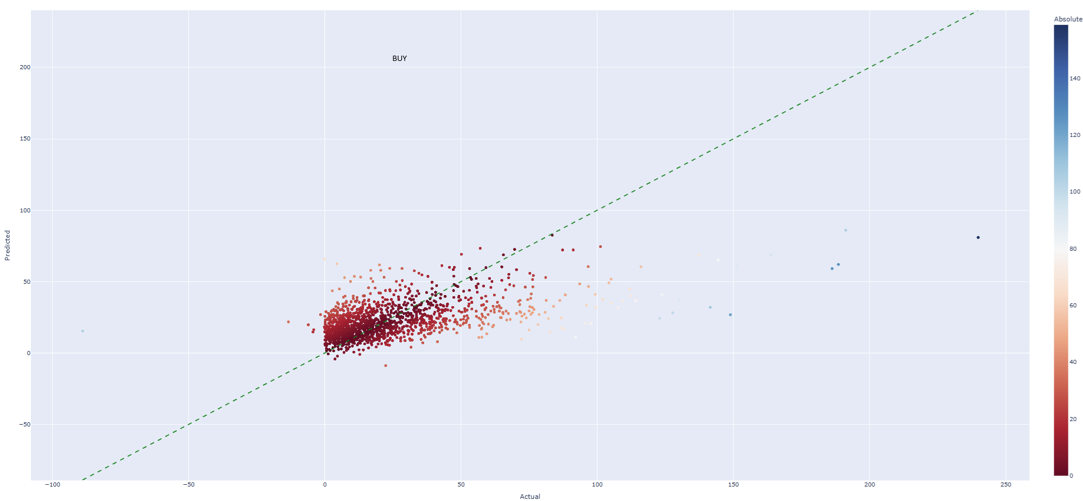


## Train Sell Model
Uses Optuna to find the best XGBoost parameters for each window then predict the test window with the best parameters.

In [ ]:


df_sell = df.copy()
df_sell['timestamp'] = pd.to_datetime(df_sell['timestamp'], errors='coerce')

 #This is the amount of candles to hold the trade.  So in this case all labels will be 2 candles ahead (8 hour trade)
max_hold = 2 
timestamp_sell = []
preds_sell_list=[]
actuals_sell_list=[]
timestamp_sell_list = []

#calculate Buy Model label which is the highest high in the next max_hold candles
future_high = pd.Series(index=df_sell.index, dtype=float)
for i in range(len(df_sell)):
    if i + 1 + max_hold <= len(df_sell):
        future_high.iloc[i] = df_sell['high'].iloc[i+1:i+1+max_hold].max()
    else:
        future_high.iloc[i] = np.nan
df_sell['max_drawdown_pips'] = (-future_high + df_sell['close']) / 0.0001

# Create max drawdown.  The lowest low in the next max_hold candles
future_low = pd.Series(index=df_sell.index, dtype=float)

for i in range(len(df_sell)):
    if i + 1 + max_hold <= len(df_sell):
        future_low.iloc[i] = df_sell['low'].iloc[i+1:i+1+max_hold].min()
    else:
        future_low.iloc[i] = np.nan

df_sell['label'] = (-future_low + df_sell['close']) / 0.0001




# Drop missing labels
df_sell = df_sell.dropna(subset=['label'])
df_sell_sorted = df_sell.sort_values(by='timestamp').reset_index(drop=True)


# Define features
exclude_cols = ['timestamp', 'date', 'label','max_drawdown_pips']
feature_cols = [col for col in df_sell.columns if col not in exclude_cols]
X = df_sell_sorted[feature_cols]
y = df_sell_sorted['label']

# Standardize features



def weighted_rmse_obj(y_true, y_pred):
    residual = y_pred - y_true
    # Apply exponential weighting, capped to prevent extreme values
    weight = np.exp(y_true / y_true.max() * 2)  # Exponential from ~1 to ~e^2 (~7.4)
    weight = np.clip(weight, 1.0, 10.0)  # Ensure weight stays in a reasonable range
    grad = 2 * residual * weight
    hess = 2 * weight
    return grad, hess



def objective(trial, X_train_sell, y_train_sell, X_val, y_val):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.4),
        "subsample": trial.suggest_float("subsample", 0.5, 1),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1),
        "gamma": trial.suggest_float("gamma", 0, 7),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 7),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 7),
    }
    model_sell = XGBRegressor(**params, objective=weighted_rmse_obj, random_state=42)

    model_sell.fit(X_train_sell, y_train_sell)
    preds = model_sell.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))


# Walk forward
# Custom sliding window
n_total = len(X)
initial_train_sell_size = int(n_total * 0.5)
slide_size = int(n_total * 0.02)

splits = []
start = initial_train_sell_size

while start < n_total:
    train_sell_idx = list(range(0, start))
    test_sell_idx = list(range(start, min(start + slide_size, n_total)))

    splits.append((train_sell_idx, test_sell_idx))
    start += slide_size

for train_sell_idx, test_sell_idx in splits:

    X_train_sell_raw = X.iloc[train_sell_idx].copy()
    X_test_sell_raw = X.iloc[test_sell_idx].copy()


    # PCA on OHLC descriptors
    ohlc_desc = pd.DataFrame({
        'upper_shadow': X_train_sell_raw['close'] - X_train_sell_raw['high'],
        'lower_shadow': X_train_sell_raw['close'] - X_train_sell_raw['low'],
        'body': X_train_sell_raw['close'] - X_train_sell_raw['open'],
        'close': X_train_sell_raw['close'] - X_train_sell_raw['close']  # all zero
    })

    pca = PCA(n_components=1)
    X_train_sell_raw['pca_ohlc'] = pca.fit_transform(ohlc_desc)
    for i in range(1, 6):
        X_train_sell_raw[f'pca_ohlc_lag_{i}'] = X_train_sell_raw['pca_ohlc'].shift(i)


    # Compute OHLC descriptors for test_sell set
    ohlc_desc_test_sell = pd.DataFrame({
        'upper_shadow': X_test_sell_raw['close'] - X_test_sell_raw['high'],
        'lower_shadow': X_test_sell_raw['close'] - X_test_sell_raw['low'],
        'body': X_test_sell_raw['close'] - X_test_sell_raw['open'],
        'close': X_test_sell_raw['close'] - X_test_sell_raw['close']  # all zero
    })

    # Transform test data using the already fitted PCA
    X_test_sell_pca = pca.transform(ohlc_desc_test_sell)

    # Convert to DataFrame and add lag features
    X_test_sell_raw['pca_ohlc'] = X_test_sell_pca

    # Add lag features to test
    for i in range(1, 6):
        X_test_sell_raw[f'pca_ohlc_lag_{i}'] = X_test_sell_raw['pca_ohlc'].shift(i)




    # Drop raw OHLC columns from train and test after PCA
    ohlc_cols = ['open', 'high', 'low', 'close']
    # Save OHLC + timestamp from original df_sell before dropping
    raw_ohlc = df_sell_sorted[['timestamp', 'open', 'high', 'low', 'close']].iloc[test_sell_idx].reset_index(drop=True)

    X_train_sell_raw.drop(columns=ohlc_cols, inplace=True)
    X_test_sell_raw.drop(columns=ohlc_cols, inplace=True)



    scaler = StandardScaler()
    X_train_sell = scaler.fit_transform(X_train_sell_raw)
    X_test_sell = scaler.transform(X_test_sell_raw)



    y_train_sell, y_test_sell = y.iloc[train_sell_idx], y.iloc[test_sell_idx]
    df_sell_window = df_sell_sorted.iloc[test_sell_idx].copy().reset_index(drop=True)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(lambda trial: objective(trial, X_train_sell, y_train_sell, X_test_sell, y_test_sell), n_trials=5)
    
    best_params = study.best_params
    best_params_df_sell = pd.DataFrame([best_params])  # Wrap in a list to create a single-row DataFrame
    

    model_sell = XGBRegressor(**best_params, objective=weighted_rmse_obj, random_state=42)


    timestamp_sell = df_sell_sorted['timestamp'].iloc[test_sell_idx].reset_index(drop=True)
    timestamp_sell_list.append(pd.Series(timestamp_sell))
    model_sell.fit(X_train_sell, y_train_sell)
   
    preds_sell = model_sell.predict(X_test_sell)
    
    # Save predictions and actuals with timestamp index
    preds_sell_list.append(pd.Series(preds_sell, index=timestamp_sell))
    actuals_sell_list.append(pd.Series(y_test_sell.values, index=timestamp_sell))






## Evaluate Sell Model

In [ ]:
# Combine predictions and actuals into single series
all_preds_sell = pd.concat(preds_sell_list)
all_actuals_sell = pd.concat(actuals_sell_list)

# Compute absolute error
all_abs_error = np.abs(all_actuals_sell - all_preds_sell)

# Calculate overall RMSE
rmse_buy = np.sqrt(mean_squared_error(all_actuals_sell, all_preds_sell))
print(f"Buy Model RMSE: {rmse_buy:.2f}")

# Create scatter plot
fig = px.scatter(
    x=all_actuals_sell,
    y=all_preds_sell,
    color=all_abs_error,
    color_continuous_scale="RdBu",
    labels={"x": "Actual", "y": "Predicted", "color": "Absolute Error"},
    title="Sell Model: Predicted vs Actual (All Sliding Windows)",
    width=1000,     # Wider
    height=600     # Taller
)

# Add y = x line
fig.add_shape(
    type="line",
    x0=all_actuals_sell.min(), y0=all_actuals_sell.min(),
    x1=all_actuals_sell.max(), y1=all_actuals_sell.max(),
    line=dict(color="green", dash="dash"),
)

fig.update_layout(coloraxis_colorbar_title="Abs Error")
fig.show()

## Results:  
**Running 15% initial training window with 1% window increments at 200 optuna trials per window**

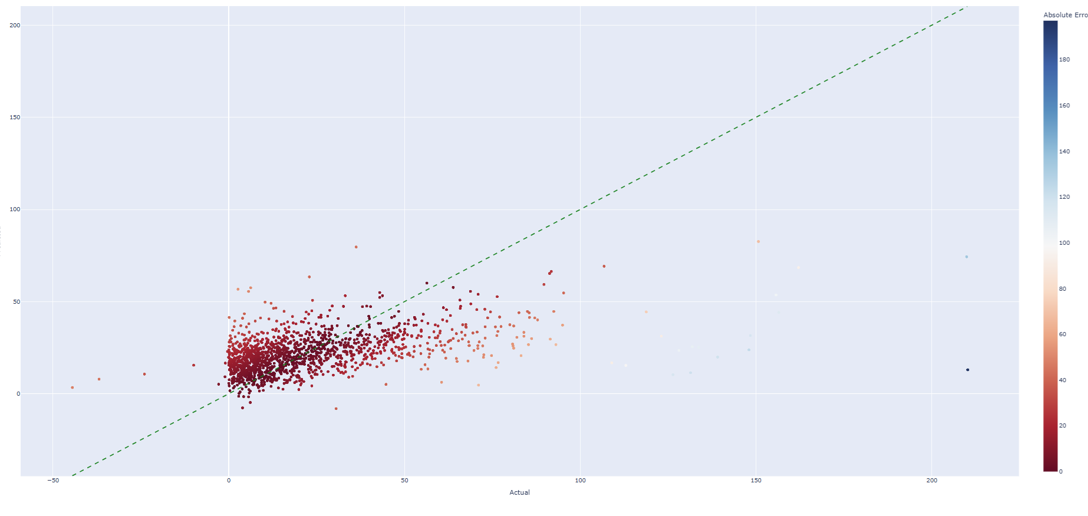

## Combo Model Prediction
**This model brings the buy and sell predictions together and predicts change in closing price from current to "max_hold" candles.**

-First step is to organize the Sell and Buy model predictions

In [ ]:

buy_df = pd.DataFrame({
    "timestamp": pd.concat(timestamp_buy_list).reset_index(drop=True),
    "buy_predicted": pd.concat(preds_buy_list).reset_index(drop=True),
    "buy_actual": pd.concat(actuals_buy_list).reset_index(drop=True)
})

sell_df = pd.DataFrame({
    "timestamp": pd.concat(timestamp_sell_list).reset_index(drop=True),
    "sell_predicted": pd.concat(preds_sell_list).reset_index(drop=True),
    "sell_actual": pd.concat(actuals_sell_list).reset_index(drop=True)
})

df_sorted = df_sell_sorted.copy()
df_sorted = df_sorted.merge(buy_df, on="timestamp", how="left")
df_sorted = df_sorted.merge(sell_df, on="timestamp", how="left")
print(df_sorted.head())
print(df_sorted.tail())

**Feature Engineering:  adding label as well as a shifted high and low actual from the previous models.  No leakage since the actuals are shifted back 'max_hold' rows**

## Feature Engineering for Combo Model


In [ ]:
df_combo = df_sorted.copy()
df_combo[['sell_actual', 'buy_actual']] = df_combo[['sell_actual', 'buy_actual']].shift(max_hold)
df_combo = df_combo.dropna(subset=['buy_predicted', 'sell_predicted','buy_actual','sell_actual']).reset_index(drop=True)
df_combo = df_combo.drop(['label'], axis=1)
df_combo['sell_actual'] = df_combo['sell_actual']*-1
df_combo['sell_predicted'] = df_combo['sell_predicted']*-1


future_high = pd.Series(index=df_combo.index, dtype=float)
for i in range(len(df_combo)):
    if i + 1 + max_hold <= len(df_combo):
        future_high.iloc[i] = df_combo['high'].iloc[i+1:i+1+max_hold].max()
    else:
        future_high.iloc[i] = np.nan
df_combo['max_drawup_pips'] = (future_high - df_combo['close']) / 0.0001

# Create max drawdown
future_low = pd.Series(index=df_combo.index, dtype=float)

for i in range(len(df_combo)):
    if i + 1 + max_hold <= len(df_combo):
        future_low.iloc[i] = df_combo['low'].iloc[i+1:i+1+max_hold].min()
    else:
        future_low.iloc[i] = np.nan

df_combo['max_drawdown_pips'] = (future_low - df_combo['close']) / 0.0001




df_combo['label'] = (df_combo['close'].shift(-max_hold) - df_combo['close'])/.0001



# Drop missing labels
df_combo = df_combo.dropna(subset=['label'])
df_combo_sorted = df_combo.sort_values(by='timestamp').reset_index(drop=True)




# Define features
exclude_cols = [ 'date', 'label','max_drawdown_pips','max_drawup_pips','timestamp','Start_Close','Future_Close']
feature_cols = [col for col in df_combo.columns if col not in exclude_cols]
X = df_combo_sorted[feature_cols]
y = df_combo_sorted['label']

print(X.head())

print("Label")
print(y.head())

## Combo Model Hyperparameter Tuning with Optuna
Uses Optuna to find the best XGBoost parameters for each window then predict the test window with the best parameters.

In [ ]:




# Standardize features


# Initialize results
all_results = []
preds_list = []
row_data_all = []
actuals_list = []
# Sliding window setup


def objective(trial, X_train, y_train, X_val, y_val):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.4),
        "subsample": trial.suggest_float("subsample", 0.5, 1),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1),
        "gamma": trial.suggest_float("gamma", 0, 7),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 7),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 7),
    }
    model = XGBRegressor(**params, objective=weighted_rmse_obj, random_state=42)

    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))



# Walk forward
# Custom sliding window
n_total = len(X)
initial_train_size = int(n_total * 0.5)
slide_size = int(n_total * 0.01)

splits = []
start = initial_train_size

while start + slide_size <= n_total:
    train_idx = list(range(0, start))
    test_idx = list(range(start, start + slide_size))
    splits.append((train_idx, test_idx))
    start += slide_size

for train_idx, test_idx in splits:

    X_train_raw = X.iloc[train_idx].copy()
    X_test_raw = X.iloc[test_idx].copy()


           # PCA on OHLC descriptors
    ohlc_desc = pd.DataFrame({
        'upper_shadow': X_train_raw['close'] - X_train_raw['high'],
        'lower_shadow': X_train_raw['close'] - X_train_raw['low'],
        'body': X_train_raw['close'] - X_train_raw['open'],
        'close': X_train_raw['close'] - X_train_raw['close']  # all zero
    })

    pca = PCA(n_components=1)
    X_train_raw['pca_ohlc'] = pca.fit_transform(ohlc_desc)
    

    
    for i in range(1, 6):
        X_train_raw[f'pca_ohlc_lag_{i}'] = X_train_raw['pca_ohlc'].shift(i)


        # Compute OHLC descriptors for test set
    ohlc_desc_test = pd.DataFrame({
        'upper_shadow': X_test_raw['close'] - X_test_raw['high'],
        'lower_shadow': X_test_raw['close'] - X_test_raw['low'],
        'body': X_test_raw['close'] - X_test_raw['open'],
        'close': X_test_raw['close'] - X_test_raw['close']  # all zero
    })

    # Transform test data using the already fitted PCA
    X_test_pca = pca.transform(ohlc_desc_test)

    # Convert to DataFrame and add lag features
    X_test_raw['pca_ohlc'] = X_test_pca

    # Add lag features to test
    for i in range(1, 6):
        X_test_raw[f'pca_ohlc_lag_{i}'] = X_test_raw['pca_ohlc'].shift(i)




    # Drop raw OHLC columns from train and test after PCA
    ohlc_cols = ['open', 'high', 'low', 'close']
    X_train_raw.drop(columns=ohlc_cols, inplace=True)
    X_test_raw.drop(columns=ohlc_cols, inplace=True)



    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train_raw)
    joblib.dump(scaler, "scaler.pkl")

    X_test = scaler.transform(X_test_raw)



   


    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    df_combo_window = df_combo_sorted.iloc[test_idx].copy().reset_index(drop=True)

    study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
    study.optimize(lambda trial: objective(trial, X_train, y_train, X_test, y_test), n_trials=10)
    
    best_params = study.best_params
    best_params_df_combo = pd.DataFrame([best_params])  # Wrap in a list to create a single-row DataFrame
    
  

    model = XGBRegressor(**best_params, objective=weighted_rmse_obj, random_state=42)



    model.fit(X_train, y_train)
    # Save model to disk

    preds = model.predict(X_test)

    preds_list.append(pd.Series(preds))
    actuals_list.append(pd.Series(y_test.values))

   # Add context columns
    df_combo_window['Start_Close'] = df_combo_window['close']
    df_combo_window['Future_Close'] = df_combo_window['close'].shift(-max_hold)

    # Drop rows with NaN future close
    df_combo_window = df_combo_window.dropna(subset=['Future_Close']).reset_index(drop=True)

    # Also trim y_test and preds to match dropped rows
    valid_len = len(df_combo_window)
    preds = preds[:valid_len]
    y_test = y_test.iloc[:valid_len]

    # Assign predictions and actuals
    df_combo_window['sell_predicted'] = preds
    df_combo_window['sell_actual'] = y_test.values

    # Select meta columns
    # Add OHLC back from df_combo_sorted
    ohlc_cols = ['open', 'high', 'low', 'close','sell_predicted','sell_actual','buy_predicted', 'buy_actual']
    ohlc_data = df_combo_sorted.iloc[test_idx][ohlc_cols].reset_index(drop=True)

    # Select meta columns
    meta_cols = df_combo_window[['timestamp', 'sell_predicted', 'sell_actual', 'Start_Close', 'Future_Close']]

    # Combine metadata, OHLC, and features
    
    # Create scaled feature DataFrame
    X_test_scaled_df_combo = pd.DataFrame(X_test, columns=X_test_raw.columns).reset_index(drop=True)
    X_test_scaled_df_combo = X_test_scaled_df_combo.iloc[:valid_len]  # match trimmed df_combo_window

    # Combine metadata and features
    df_combo_full = pd.concat([meta_cols, ohlc_data, X_test_scaled_df_combo], axis=1)

    # Append for final merge
    row_data_all.append(df_combo_full)




    

 






## Combo Model Evaluation


In [ ]:
import plotly.express as px

# Concatenate all predictions
all_preds = pd.concat(preds_list, ignore_index=True)
all_actuals = pd.concat(actuals_list, ignore_index=True)

# Compute absolute error
all_abs_error = np.abs(all_preds - all_actuals)



# Calculate overall RMSE
rmse_buy = np.sqrt(mean_squared_error(all_actuals, all_preds))
print(f"Combo Model RMSE: {rmse_buy:.2f}")


# Create scatter plot
fig = px.scatter(
    x=all_actuals,
    y=all_preds,
    color=all_abs_error,
    color_continuous_scale="RdBu",
    labels={"x": "Actual", "y": "Predicted", "color": "Absolute Error"},
    title="Predicted vs Actual (All Sliding Windows)",
    width=1000,     # Wider
    height=600     # Taller
)

# Add y=x line
fig.add_shape(
    type="line",
    x0=all_actuals.min(), y0=all_actuals.min(),
    x1=all_actuals.max(), y1=all_actuals.max(),
    line=dict(color="green", dash="dash")
)

fig.show()

## FULL RESULTS:
This is my final result using my full feature model with 1% window shifts startging at 15% of the data. Once again the feature in this notebook is a small portion of my production features.  This notebook also only goes through 10 Optuna trials during training while I usually use a minimum of 100.

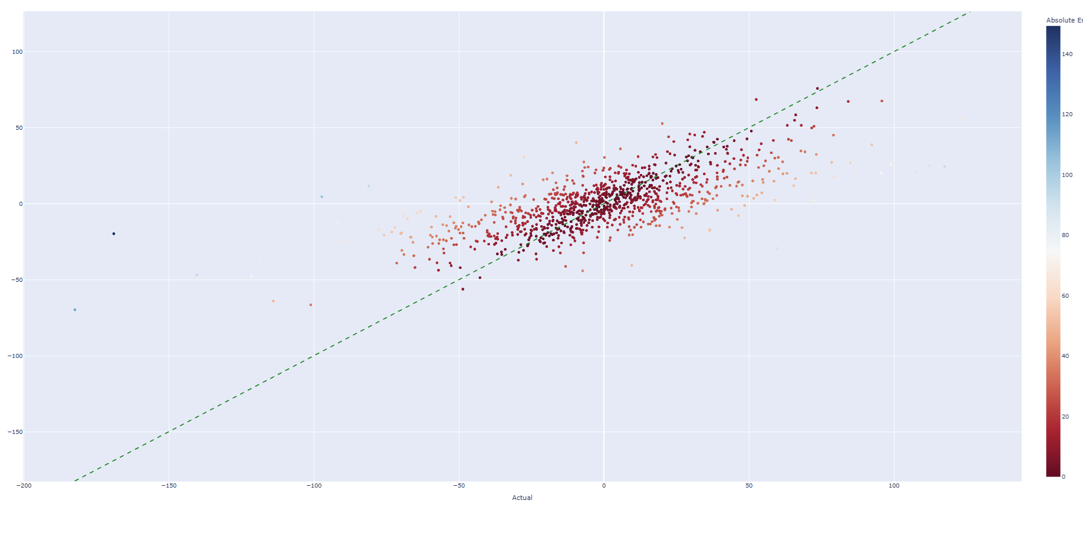

## Conclusion

This notebook demonstrates a modular machine learning pipeline for predicting short-term price movements in the EUR/USD 4-hour chart using supervised learning. The workflow begins by generating engineered features and labels tailored to each trade direction—separately modeling potential gains for buy and sell positions using XGBoost.

Each direction-specific model is trained and evaluated using a time series-aware sliding window approach. Predictions and actual outcomes across all windows are aggregated and visualized to assess performance using scatter plots and RMSE metrics. This split-model approach enables more targeted learning by focusing on directional price dynamics independently.

Once validated, the outputs of both models are merged and fed into a combo model, which synthesizes the predictions along with other engineered features to generate a unified trading signal. This structure allows the system to evaluate trade-offs and conflicting signals, improving overall precision.

The result is a layered and interpretable system with strong modularity—each model can be trained, tuned, and evaluated independently while still contributing to a cohesive trading strategy. Although demonstrated here on the EUR/USD pair, the design is flexible enough to be applied to other financial assets or domains like healthcare analytics, simply by changing the input data and retraining.

As demonstrated by the prediction overlays below, the production combo model has performed exceptionally well, with most predicted trades falling outside the red error zones—indicating a high win rate. I’m currently testing the model in live market conditions, and early signs are promising.

Next, I plan to develop a reinforcement learning module to manage trade execution dynamically, using these predictions as inputs—taking the system one step closer to fully automated intelligent trading.

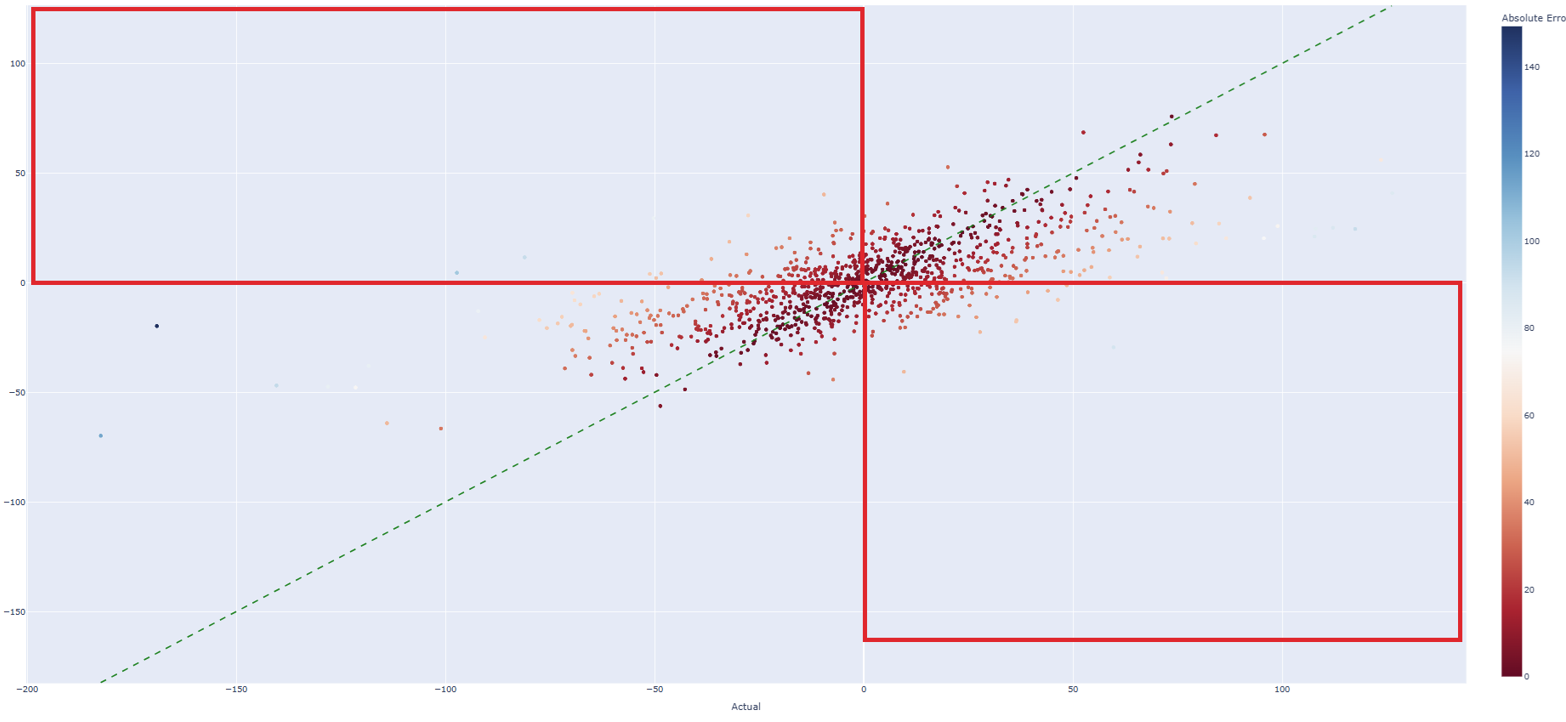